# 04 - Preprocessing
## Airbnb Price Prediction - Austin, TX

**Purpose of this notebook**  
Turn the feature-engineered dataset into model-ready arrays. This is the last 
stop before modeling, and the boundary at which the train/test split is 
materialized: from here on, the test set is sealed until the final evaluation 
in notebook 07. The fitted preprocessor is exported as a reusable artifact 
that every downstream modeling notebook will plug into its pipeline.

**What this notebook does NOT do**  
- No feature engineering (done in `03_Features.ipynb`)
- No model fitting or hyperparameter search (deferred to notebooks 05 and 06)
- No evaluation on the test set (deferred to `07_Final_Evaluation.ipynb`)
- No statistic of any kind computed from the test set

**Anti-leakage discipline**  
> The preprocessor is fitted on the training set only. The test set is 
> transformed using the parameters learned on the train. In the modeling 
> notebooks, the target encoder will be re-fitted inside each cross-validation 
> fold; the `preprocessor.pkl` exported here is the one used for the final 
> holdout evaluation.

**Input**: `data/processed/Austin/data_features.parquet` (10,503 rows × 15 columns: 14 features + `price`)  
**Outputs**:  
- `data/processed/Austin/X_train.parquet`, `X_test.parquet`, `y_train.parquet`, `y_test.parquet`  
- `models/preprocessor.pkl`: the fitted `ColumnTransformer`

**Outline**
1. Setup & Data Loading
2. Target transformation - log1p(price)
3. Train/Test split - stratified on neighbourhood_cleansed
4. Preprocessor design - ColumnTransformer with three branches
5. Fit on train and transform both splits
6. Export

## 1. Setup & Data Loading

We load the parquet output of Notebook 03. Parquet preserves dtypes, so the 
categorical columns (`room_type`, `property_type`, `amenity_tier`) and the 
integer-coded location columns (`neighbourhood_cleansed`, `geo_cluster`) 
arrive already typed and require no reparsing.

The preprocessing toolkit comes entirely from scikit-learn: `train_test_split` 
for the stratified split, `ColumnTransformer` and `Pipeline` to wire the 
per-column transforms together, `SimpleImputer` and `StandardScaler` for the 
numeric branch, `OneHotEncoder` for the low-cardinality categoricals, and 
`TargetEncoder` for the two high-cardinality location columns. `joblib` 
handles the export of the fitted preprocessor.

We also re-run a brief sanity check on the input dataset to confirm shape, 
dtypes, and the absence of missing values reported at the end of Notebook 03. 
If any of these drift, the rest of the notebook would be built on a wrong 
assumption, so it is worth a few seconds of verification.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

INPUT_PATH = '../data/processed/Austin/data_features.parquet'
df = pd.read_parquet(INPUT_PATH)

print('=== Shape ===')
print(f'{df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('=== Dtypes and NaN audit ===')
audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'nan_count': df.isna().sum(),
})
print(audit)

=== Shape ===
10,503 rows x 15 columns

=== Dtypes and NaN audit ===
                            dtype  non_null  nan_count
price                     float64     10503          0
accommodates                int64     10503          0
bedrooms                  float64     10503          0
beds                      float64     10503          0
bathrooms_clean           float64     10503          0
availability_365            int64     10503          0
distance_to_downtown_km   float64     10503          0
listings_density_500m       int64     10503          0
guests_per_bedroom        float64     10503          0
bathrooms_per_guest       float64     10503          0
room_type                     str     10503          0
property_type                 str     10503          0
neighbourhood_cleansed      int64     10503          0
geo_cluster                 int32     10503          0
amenity_tier             category     10503          0


## 2. Target transformation - log1p(price)

The EDA established empirically that `price` is strongly right-skewed: a few 
luxury listings stretch the upper tail well past the bulk of the distribution, 
even after the $2,500 cap applied in Notebook 02. Fitting a regression directly 
on raw prices would let those high-end listings dominate the loss, which is 
not the regime our app cares about: hosts pricing a new listing are 
overwhelmingly in the $50 to $400 range.

We model `log1p(price)` instead of `log(price)` for two reasons. First, 
`log1p` is numerically safer (defined at zero), which costs us nothing since 
the price floor is $10. Second, `log1p` is the de facto convention for skewed 
non-negative targets in scikit-learn pipelines and pairs cleanly with `expm1` 
for inverse-transforming predictions at inference time.

We quantify the improvement with the sample skewness before and after the 
transformation. A value close to zero indicates a near-symmetric distribution, 
which is the regime where linear models behave best and where tree-based 
models train more stably.

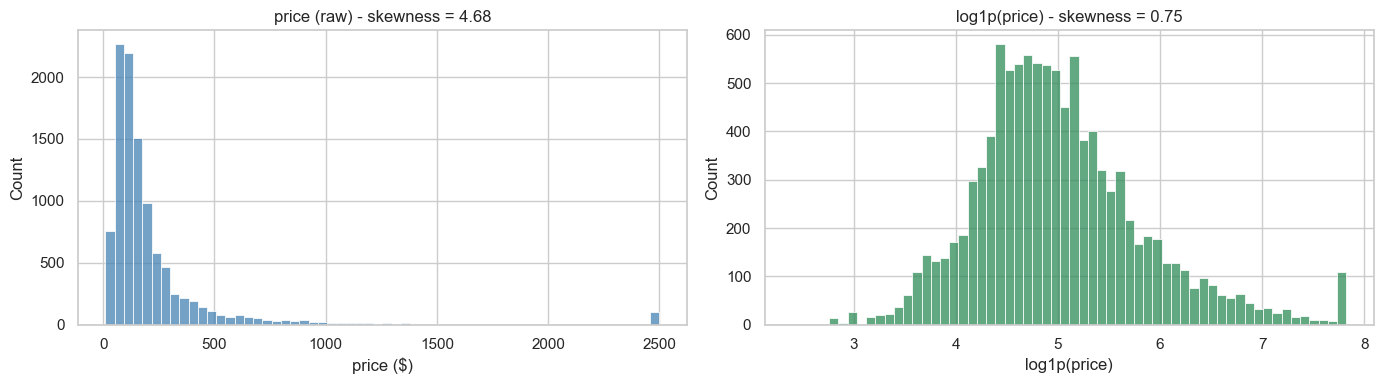

Raw price       - mean $228, median $135, skew +4.68
log1p(price)    - mean 5.011, median 4.913, skew +0.75


In [2]:
from scipy.stats import skew

y = np.log1p(df['price'])

skew_raw = skew(df['price'])
skew_log = skew(y)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['price'], bins=60, ax=axes[0], color='steelblue')
axes[0].set_title(f'price (raw) - skewness = {skew_raw:.2f}')
axes[0].set_xlabel('price ($)')

sns.histplot(y, bins=60, ax=axes[1], color='seagreen')
axes[1].set_title(f'log1p(price) - skewness = {skew_log:.2f}')
axes[1].set_xlabel('log1p(price)')

plt.tight_layout()
plt.show()

print(f'Raw price       - mean ${df["price"].mean():.0f}, median ${df["price"].median():.0f}, skew {skew_raw:+.2f}')
print(f'log1p(price)    - mean {y.mean():.3f}, median {y.median():.3f}, skew {skew_log:+.2f}')

## 3. Train/Test split - stratified on neighbourhood_cleansed

We split the data 80/20 with stratification on `neighbourhood_cleansed`. The 
EDA showed that ZIP-level location is the single strongest price driver in 
Austin (3x spread across neighborhoods), so a random split could easily 
produce a test set whose neighborhood mix differs from the train set, biasing 
the holdout evaluation. Stratifying ensures both splits share the same 
geographic composition.

Two practical points:
- The split is performed on the original dataframe, then `y` is replaced by 
  its `log1p` version for both train and test. We carry the raw price 
  alongside as `y_train_raw` / `y_test_raw` for later dollar-scale reporting 
  in Notebook 07.
- Some neighborhoods contain very few listings. Stratification requires at 
  least two observations per stratum, so we check the distribution first. If 
  any neighborhood has fewer than two listings, stratification would fail and 
  we would need to merge them into an "other" bucket. The Notebook 02 cleanup 
  should have prevented this, but we verify rather than assume.

After the split, we confirm that the proportion of each neighborhood is 
preserved across train and test, which is the whole point of stratification.

In [3]:
# Sanity check: do all neighborhoods have at least 2 listings?
nbhd_counts = df['neighbourhood_cleansed'].value_counts()
print(f'Number of distinct neighborhoods: {nbhd_counts.shape[0]}')
print(f'Smallest neighborhood: {nbhd_counts.min()} listings')
print(f'Neighborhoods with < 2 listings: {(nbhd_counts < 2).sum()}')
print(f'Neighborhoods with < 5 listings: {(nbhd_counts < 5).sum()}')

# Build features / target
X = df.drop(columns=['price'])
y_raw = df['price']
y = np.log1p(y_raw)

# Stratified split
X_train, X_test, y_train, y_test, y_train_raw, y_test_raw = train_test_split(
    X, y, y_raw,
    test_size=0.20,
    stratify=df['neighbourhood_cleansed'],
    random_state=RANDOM_STATE,
)

print()
print('=== Split shapes ===')
print(f'X_train: {X_train.shape},  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape},   y_test : {y_test.shape}')
print(f'Train share: {len(X_train) / len(X):.1%}')

# Verify stratification: top-10 neighborhoods, proportion in train vs test
top10 = nbhd_counts.head(10).index
prop_train = X_train['neighbourhood_cleansed'].value_counts(normalize=True)
prop_test  = X_test['neighbourhood_cleansed'].value_counts(normalize=True)

strat_check = pd.DataFrame({
    'train_share': prop_train.loc[top10].values,
    'test_share':  prop_test.loc[top10].values,
}, index=top10)
strat_check['abs_diff'] = (strat_check['train_share'] - strat_check['test_share']).abs()

print()
print('=== Stratification check (top-10 neighborhoods) ===')
print(strat_check.round(4))
print()
print(f'Max abs diff across all neighborhoods: {(prop_train - prop_test).abs().max():.4f}')

Number of distinct neighborhoods: 43
Smallest neighborhood: 5 listings
Neighborhoods with < 2 listings: 0
Neighborhoods with < 5 listings: 0

=== Split shapes ===
X_train: (8402, 14),  y_train: (8402,)
X_test : (2101, 14),   y_test : (2101,)
Train share: 80.0%

=== Stratification check (top-10 neighborhoods) ===
                        train_share  test_share  abs_diff
neighbourhood_cleansed                                   
78704                        0.1426      0.1428    0.0002
78702                        0.1150      0.1152    0.0002
78701                        0.0857      0.0857    0.0000
78745                        0.0559      0.0557    0.0003
78741                        0.0539      0.0538    0.0001
78703                        0.0440      0.0443    0.0002
78723                        0.0357      0.0357    0.0000
78744                        0.0345      0.0347    0.0002
78705                        0.0336      0.0338    0.0002
78758                        0.0333      0.0333 

## 4. Preprocessor design - ColumnTransformer with three branches

The 14 features fall into three groups that require fundamentally different 
treatment:

**Numeric features (9 columns)**: `accommodates`, `bedrooms`, `beds`, 
`bathrooms_clean`, `availability_365`, `distance_to_downtown_km`, 
`listings_density_500m`, `guests_per_bedroom`, `bathrooms_per_guest`.

Pipeline: `SimpleImputer(median)` then `StandardScaler`. Median imputation is 
robust to the outliers we saw in the EDA (a single luxury listing with 16 
beds would distort a mean-based imputer). Standard scaling is required by 
the linear models in Notebook 05 (Ridge, Lasso, ElasticNet penalize 
coefficients on a common scale) and is harmless for tree-based models in 
Notebook 06. The current dataset has no missing values, but we keep the 
imputer as a defensive layer for the Streamlit app, where a user could leave 
an optional field blank.

**Low-cardinality categoricals (3 columns)**: `room_type` (4 values), 
`property_type` (dozens of values, long tail), `amenity_tier` (3 ordered 
values).

Pipeline: `SimpleImputer(most_frequent)` then `OneHotEncoder` with 
`min_frequency=5` and `handle_unknown='infrequent_if_exist'`. The frequency 
threshold collapses rare `property_type` values (e.g. "Castle", "Treehouse" 
with one or two listings each) into a single `infrequent_sklearn` bin, 
preventing the explosion of one-hot dimensions and the overfitting that 
would follow. The `handle_unknown` setting is the inference-time safety net: 
when the Streamlit app encounters a property type that did not appear in 
training, it lands in the infrequent bin rather than raising an error.

**High-cardinality categoricals (2 columns)**: `neighbourhood_cleansed` 
(43 Austin ZIP codes) and `geo_cluster` (20 KMeans clusters).

Pipeline: `TargetEncoder` (no imputer needed, no NaN present). One-hot 
encoding these would add 60+ columns of mostly-zero indicators, which hurts 
both linear and tree models. Target encoding replaces each category with a 
smoothed average of `log1p(price)` learned in cross-fitting, capturing the 
location signal in a single numeric column per group. Scikit-learn's 
`TargetEncoder` (since 1.3) handles the smoothing automatically and uses 
cross-fitting on `fit_transform` to avoid the classic target-leakage trap. 
We fit it on the training set only here; the modeling notebooks will 
re-fit it inside each CV fold for the same anti-leakage reason.

**Why not a single shared imputer upstream?** Numeric and categorical 
features need different imputation strategies (median vs mode). The 
`ColumnTransformer` keeps

In [4]:
# Column groups, aligned with the project specification (table 4.1)
NUMERIC_COLS = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms_clean', 'availability_365',
    'distance_to_downtown_km', 'listings_density_500m',
    'guests_per_bedroom', 'bathrooms_per_guest',
]
OHE_COLS = ['room_type', 'property_type', 'amenity_tier']
TARGET_ENC_COLS = ['neighbourhood_cleansed', 'geo_cluster']

# Sanity check: every feature in X_train is covered exactly once
covered = set(NUMERIC_COLS) | set(OHE_COLS) | set(TARGET_ENC_COLS)
missing = set(X_train.columns) - covered
extra = covered - set(X_train.columns)
assert not missing, f'Features not assigned to a branch: {missing}'
assert not extra, f'Branch references nonexistent columns: {extra}'
assert len(covered) == X_train.shape[1] == 14, 'Branch coverage mismatch'
print(f'Branch coverage OK: {len(NUMERIC_COLS)} numeric + {len(OHE_COLS)} OHE + {len(TARGET_ENC_COLS)} target-enc = {len(covered)} features')

# Numeric branch
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Low-cardinality categorical branch
ohe_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(
        min_frequency=5,
        handle_unknown='infrequent_if_exist',
        sparse_output=False,
    )),
])

# High-cardinality categorical branch (no imputer: no NaN)
target_enc_pipeline = Pipeline(steps=[
    ('target_enc', TargetEncoder(
        target_type='continuous',
        smooth='auto',
        random_state=RANDOM_STATE,
    )),
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, NUMERIC_COLS),
        ('ohe', ohe_pipeline, OHE_COLS),
        ('tgt', target_enc_pipeline, TARGET_ENC_COLS),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

# Display structure
from sklearn import set_config
set_config(display='diagram')
preprocessor

Branch coverage OK: 9 numeric + 3 OHE + 2 target-enc = 14 features


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

## 5. Fit on train and transform both splits

We fit the preprocessor on `X_train` and `y_train` (the log1p-transformed 
target). The target is needed because the `TargetEncoder` branch uses it to 
learn the per-category averages; the numeric and OHE branches ignore it. We 
then transform both splits with the same fitted object.

After transformation, the output is a NumPy array. We wrap it back into a 
DataFrame using `get_feature_names_out()` so the downstream notebooks can 
inspect column names, build SHAP plots with proper labels, and serialize the 
result as parquet (parquet requires column names).

Three checks before exporting:
- Shape consistency: train and test should have the same number of columns 
  after transformation.
- No NaN introduced by the transformations.
- The column count is plausible given the OHE expansion (9 numeric + ~10-15 
  one-hot dummies + 2 target-encoded = roughly 20-25 columns total, exact 
  number depends on how `min_frequency=5` collapses rare property types).

In [5]:
# Fit on train only - the test set is not touched
preprocessor.fit(X_train, y_train)

# Transform both splits
X_train_t = preprocessor.transform(X_train)
X_test_t  = preprocessor.transform(X_test)

# Recover output column names and wrap into DataFrames
feature_names = preprocessor.get_feature_names_out()
X_train_t = pd.DataFrame(X_train_t, columns=feature_names, index=X_train.index)
X_test_t  = pd.DataFrame(X_test_t,  columns=feature_names, index=X_test.index)

print('=== Transformed shapes ===')
print(f'X_train_t: {X_train_t.shape}')
print(f'X_test_t : {X_test_t.shape}')
print()
print(f'NaN in X_train_t: {X_train_t.isna().sum().sum()}')
print(f'NaN in X_test_t : {X_test_t.isna().sum().sum()}')
print()
print('=== Output columns ===')
for col in feature_names:
    print(f'  {col}')
print()
print('=== Numeric features - post-scaling summary (train) ===')
num_summary = X_train_t[NUMERIC_COLS].agg(['mean', 'std']).T.round(4)
print(num_summary)

=== Transformed shapes ===
X_train_t: (8402, 51)
X_test_t : (2101, 51)

NaN in X_train_t: 0
NaN in X_test_t : 0

=== Output columns ===
  accommodates
  bedrooms
  beds
  bathrooms_clean
  availability_365
  distance_to_downtown_km
  listings_density_500m
  guests_per_bedroom
  bathrooms_per_guest
  room_type_Entire home/apt
  room_type_Hotel room
  room_type_Private room
  room_type_Shared room
  property_type_Camper/RV
  property_type_Entire bungalow
  property_type_Entire cabin
  property_type_Entire condo
  property_type_Entire cottage
  property_type_Entire guest suite
  property_type_Entire guesthouse
  property_type_Entire home
  property_type_Entire loft
  property_type_Entire rental unit
  property_type_Entire resort
  property_type_Entire serviced apartment
  property_type_Entire townhouse
  property_type_Entire vacation home
  property_type_Entire villa
  property_type_Private room
  property_type_Private room in bed and breakfast
  property_type_Private room in condo
  prop

## 6. Export

Three artifacts leave this notebook:

- The four splits (`X_train`, `X_test`, `y_train`, `y_test`) as parquet 
  files in `data/processed/Austin/`. We export the **untransformed** feature 
  matrices: notebooks 05 and 06 will plug the preprocessor into a `Pipeline` 
  and refit it inside each CV fold, which requires raw inputs. The 
  transformation performed in Section 5 is kept in-notebook for verification 
  only and is not persisted.
- The fitted `preprocessor.pkl` in `models/`. This is the version used for 
  the final holdout evaluation in Notebook 07 and the one shipped with the 
  Streamlit app. Inside the modeling notebooks (05 and 06), the preprocessor 
  is re-fitted within each CV fold to keep target encoding leak-free during 
  validation.
- The raw-dollar versions of the target (`y_train_raw`, `y_test_raw`) are 
  also persisted; Notebook 07 needs them to report MAE in dollars and to 
  compute the business-facing "% predictions within X%" metrics.

We pair the `X` and `y` arrays explicitly by exporting them with their 
original indices preserved, so the modeling notebooks can verify alignment 
after loading.

In [6]:
OUTPUT_DIR = '../data/processed/Austin'
MODELS_DIR = '../models'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Transformed features
X_train.to_parquet(f'{OUTPUT_DIR}/X_train.parquet')
X_test.to_parquet(f'{OUTPUT_DIR}/X_test.parquet')

# Raw (untransformed) features - the preprocessor will be applied inside CV folds
pd.DataFrame({'price_log1p': y_train, 'price': y_train_raw}).to_parquet(
    f'{OUTPUT_DIR}/y_train.parquet'
)
pd.DataFrame({'price_log1p': y_test, 'price': y_test_raw}).to_parquet(
    f'{OUTPUT_DIR}/y_test.parquet'
)

# Fitted preprocessor
joblib.dump(preprocessor, f'{MODELS_DIR}/preprocessor.pkl')

# Confirmation
print('=== Files exported ===')
for fname in ['X_train.parquet', 'X_test.parquet', 'y_train.parquet', 'y_test.parquet']:
    path = f'{OUTPUT_DIR}/{fname}'
    size_kb = os.path.getsize(path) / 1024
    print(f'  {path}  ({size_kb:,.1f} KB)')

preproc_path = f'{MODELS_DIR}/preprocessor.pkl'
print(f'  {preproc_path}  ({os.path.getsize(preproc_path) / 1024:,.1f} KB)')

print()
print('=== Round-trip verification ===')
X_train_check = pd.read_parquet(f'{OUTPUT_DIR}/X_train.parquet')
y_train_check = pd.read_parquet(f'{OUTPUT_DIR}/y_train.parquet')
print(f'X_train reloaded: {X_train_check.shape}, dtypes OK: {(X_train_check.dtypes == X_train.dtypes).all()}')
print(f'y_train reloaded: {y_train_check.shape}, columns: {list(y_train_check.columns)}')
print(f'Index alignment X/y train: {(X_train_check.index == y_train_check.index).all()}')

=== Files exported ===
  ../data/processed/Austin/X_train.parquet  (209.0 KB)
  ../data/processed/Austin/X_test.parquet  (62.1 KB)
  ../data/processed/Austin/y_train.parquet  (80.4 KB)
  ../data/processed/Austin/y_test.parquet  (24.5 KB)
  ../models/preprocessor.pkl  (8.3 KB)

=== Round-trip verification ===
X_train reloaded: (8402, 14), dtypes OK: True
y_train reloaded: (8402, 2), columns: ['price_log1p', 'price']
Index alignment X/y train: True


## Handoff to 05_Modeling_Linear

The training set has 8,402 rows and 14 raw features; the test set has 2,101 
rows and the same 14 columns. The preprocessor will expand these to 51 
columns when fitted inside each CV fold of Notebook 05.

**Available artifacts**
- `data/processed/Austin/X_train.parquet`, `X_test.parquet`: raw feature 
  matrices (14 columns, native dtypes), indices aligned with their targets.
- `data/processed/Austin/y_train.parquet`, `y_test.parquet`: two-column 
  frames with `price_log1p` (modeling target) and `price` (raw dollars).
- `models/preprocessor.pkl`: the fitted `ColumnTransformer` for the final 
  holdout evaluation in Notebook 07 and for the Streamlit app.

**What Notebook 05 will do**
Fit linear baselines (plain OLS, Ridge, Lasso, ElasticNet) with 5-fold 
cross-validation stratified on `neighbourhood_cleansed`. The 33 dummies 
produced by `property_type` make this a textbook setting for L1/L2 
regularization: we expect Lasso to zero out the rare property dummies that 
survived the `min_frequency=5` threshold, and Ridge to redistribute weight 
across the correlated capacity features (`accommodates`, `bedrooms`, `beds`) 
that the EDA flagged as collinear. The headline metric is RMSE on 
`log1p(price)`; we also track MAE in dollars (after `expm1` inverse) for 
interpretability, and we report the train/validation gap explicitly to 
catch any drift above the 15% threshold set in the project specification.

**Anti-leakage note for Notebook 05**
The `preprocessor.pkl` exported here was fitted on the full training set. 
Inside the cross-validation loop of Notebook 05, the preprocessor must be 
re-instantiated and re-fitted within each fold so the `TargetEncoder` does 
not see the validation fold's prices. We will use 
`sklearn.pipeline.Pipeline([('preprocessor', ColumnTransformer(...)), 
('model', ...)])` with the raw `X_train` (pre-transformation) to make this 
automatic.